In [150]:
import os

import pandas as pd
import numpy as np

from torch.utils.data import TensorDataset, DataLoader, random_split, Dataset, Subset
import torchvision.transforms as T
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder


import random

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image,ImageEnhance

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

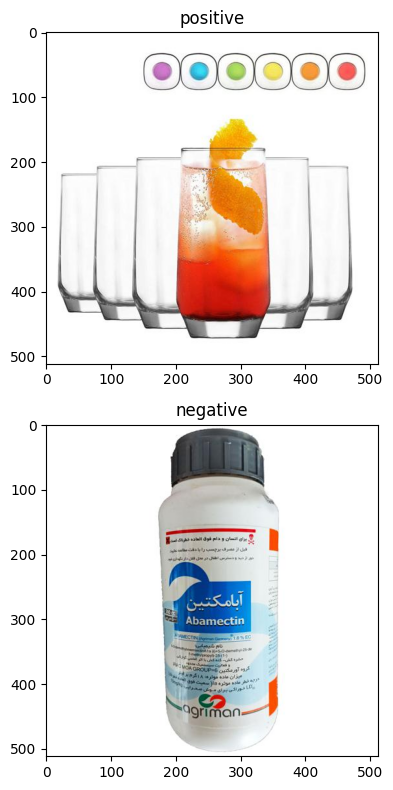

In [151]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('data/train/positive/Sample_150.jpg')
img2 = mpimg.imread('data/train/negative/Sample_150.jpg')

fig, axes = plt.subplots(2, 1, figsize=(6, 8))

axes[0].imshow(img1)
axes[0].set_title('positive')

axes[1].imshow(img2)
axes[1].set_title('negative')

plt.tight_layout()

plt.show()


In [152]:
# 1. Define a minimal transform to load images and convert to tensor
data_transform = transforms.Compose([
    transforms.Resize((512, 512)), # Use the same size you plan to use for training
    transforms.ToTensor(),
])

# 2. Load the dataset
dataset = ImageFolder(root='data/train/', transform=data_transform)
data_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

# 4. Calculate Mean and Standard Deviation
print("Calculating mean and std...")

# Initialize tensors to accumulate sum of pixel values and sum of squared pixel values
sum_pixels = torch.zeros(3, dtype=torch.float64)
sum_squared_pixels = torch.zeros(3, dtype=torch.float64)
total_pixels = 0

# Iterate through the data_loader
for i, (images, _) in enumerate(data_loader):
    # images shape: (batch_size, channels, height, width)
    batch_size = images.shape[0]
    
    # Accumulate sum of pixel values
    sum_pixels += torch.sum(images, dim=[0, 2, 3]) # Sum over batch, height, width for each channel
    
    # Accumulate sum of squared pixel values
    sum_squared_pixels += torch.sum(images**2, dim=[0, 2, 3])
    
    # Accumulate total number of pixels processed
    total_pixels += batch_size * images.shape[2] * images.shape[3] # batch_size * height * width

    if (i + 1) % 10 == 0: # Print progress every 10 batches
        print(f"Processed batch {i+1}/{len(data_loader)}")

# Calculate Mean
# Need to divide by the total number of pixels *per channel*
mean_per_channel = sum_pixels / total_pixels 

total_images_in_dataset = len(dataset)
height, width = dataset[0][0].shape[1], dataset[0][0].shape[2] # Get H, W from first image
total_pixels_per_channel = total_images_in_dataset * height * width

mean_per_channel = sum_pixels / total_pixels_per_channel

# Calculate Variance
# Variance = E[X^2] - (E[X])^2
# variance_per_channel = (sum_squared_pixels / total_pixels_per_channel) - (mean_per_channel**2)
variance_per_channel = (sum_squared_pixels / total_pixels_per_channel) - (mean_per_channel**2)

# Calculate Standard Deviation
std_per_channel = torch.sqrt(variance_per_channel)

print("\n--- Calculated Mean and Std ---")
print(f"Mean: {mean_per_channel.tolist()}")
print(f"Std: {std_per_channel.tolist()}")


Calculating mean and std...
Processed batch 10/135
Processed batch 20/135
Processed batch 30/135
Processed batch 40/135
Processed batch 50/135
Processed batch 60/135
Processed batch 70/135
Processed batch 80/135
Processed batch 90/135
Processed batch 100/135
Processed batch 110/135
Processed batch 120/135
Processed batch 130/135

--- Calculated Mean and Std ---
Mean: [0.8029808599169341, 0.7838535304392893, 0.7725147349216032]
Std: [0.29466924387076265, 0.3078778190126041, 0.3188330128303686]


In [153]:
use_cuda = torch.cuda.is_available()

torch.manual_seed(143421)
if use_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(use_cuda)

False


In [154]:
train_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.1),
    transforms.RandomAffine(degrees=0, shear=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_per_channel.tolist(), 
                         std=std_per_channel.tolist()),
])

# Test/validation data transforms
test_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_per_channel.tolist(), 
                         std=std_per_channel.tolist()),
])


In [155]:
# Load the datasets
batch_size = 32
seed = 42
val_split_ratio = 0.2

train_data = datasets.ImageFolder('data/train/', transform=train_transform)

dataset_size = len(train_data)
val_size = int(val_split_ratio * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = random_split(
    train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)


In [156]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # Validation/Test loader

print(f"Size of training dataset: {len(train_dataset)}")
print(f"Size of validation dataset: {len(val_dataset)}")

Size of training dataset: 6866
Size of validation dataset: 1716


In [157]:
class UnlabeledImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_path 


test_data = UnlabeledImageFolder('data/test/', transform=test_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Number of test images loaded: {len(test_data)}")


Number of test images loaded: 1097


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4313524..0.16000432].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7250242..0.71349335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7250242..0.27070212].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.219306..0.71349335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3676653..0.6642943].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7250242..0.71349335].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.72

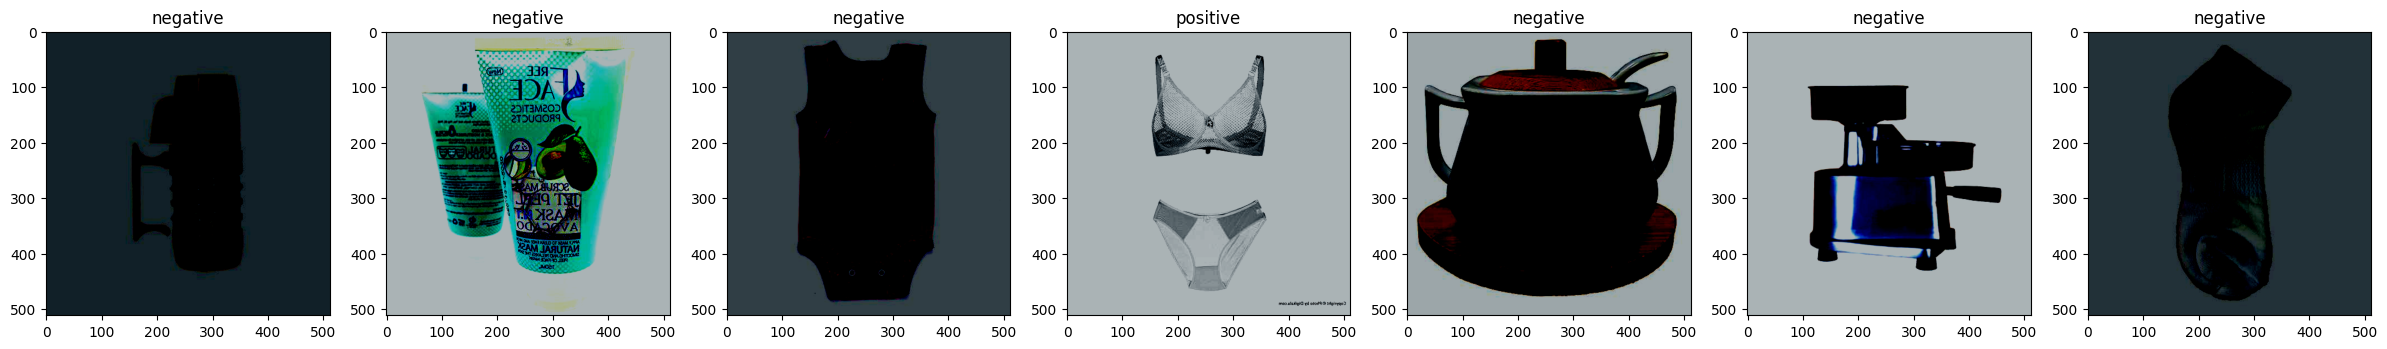

In [158]:
# Function to display images in a grid with labels
def show_images(loader, classes, num_images=5):
    # Get a batch of images and labels
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    # Select num_images randomly from the batch
    indices = np.random.choice(range(len(images)), num_images, replace=False)
    images = images[indices]
    labels = labels[indices]
    
    # Convert images back to numpy array for visualization
    images = images.numpy()
    
    fig, axes = plt.subplots(1, len(images), figsize=(30, 20))
    for idx, img in enumerate(images):
        img = np.transpose(img, (1, 2, 0))  # Change shape from (C, H, W) to (H, W, C)
        if img.shape[2] == 1:  # Grayscale image
            img = img.squeeze()
            axes[idx].imshow(img, cmap='gray')
        else:  # RGB image
            axes[idx].imshow(img)
        axes[idx].set_title(classes[labels[idx]])  # Display the label as the title
        axes[idx].axis('on')
    plt.show()

# Assuming you have two classes: 'class0' and 'class1'
classes = train_data.classes  # Get the class names from the dataset

# Display some images from the training loader with labels
show_images(train_loader, classes, num_images=7)

In [159]:
len(train_data.classes)

2

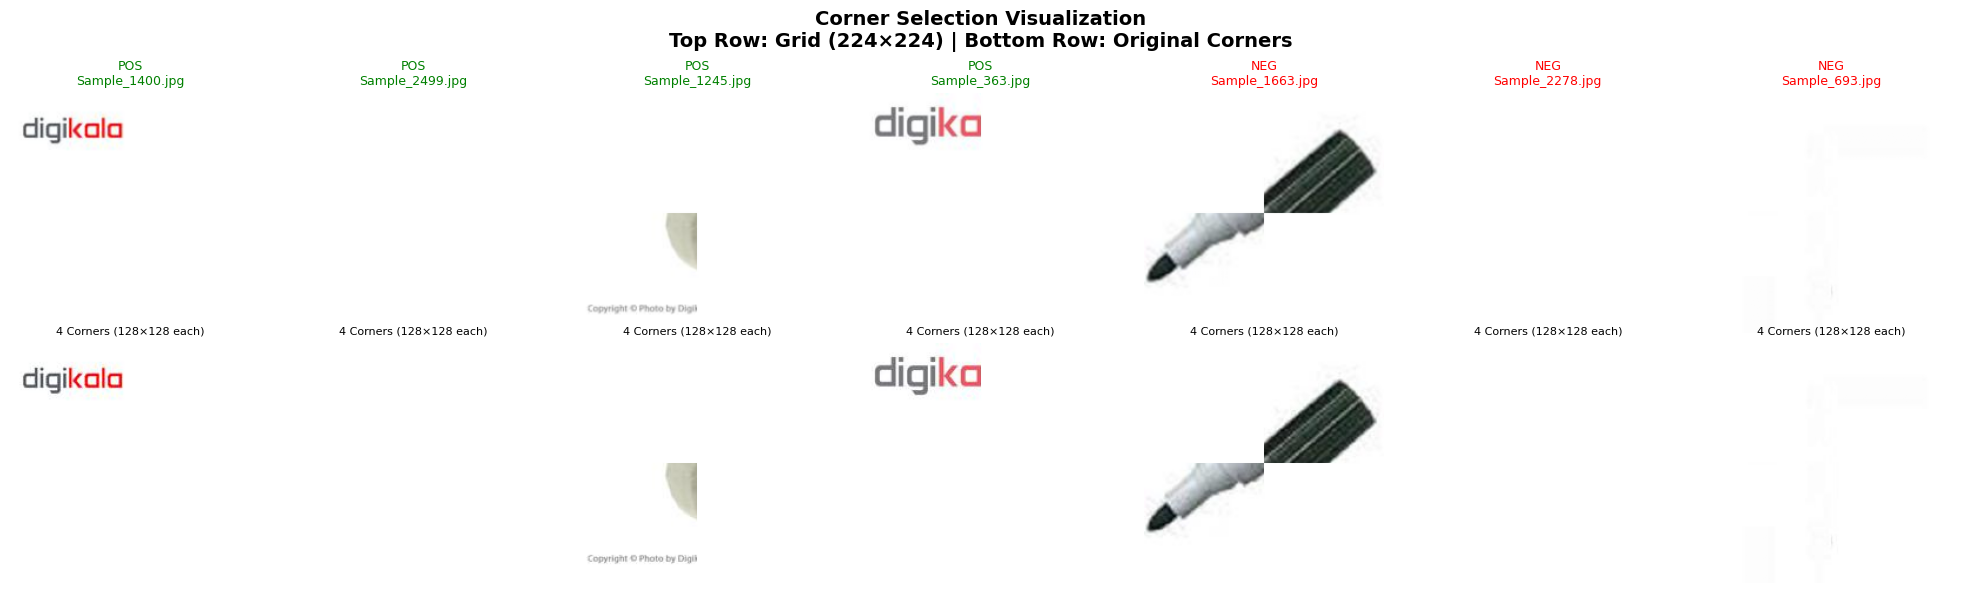


example:


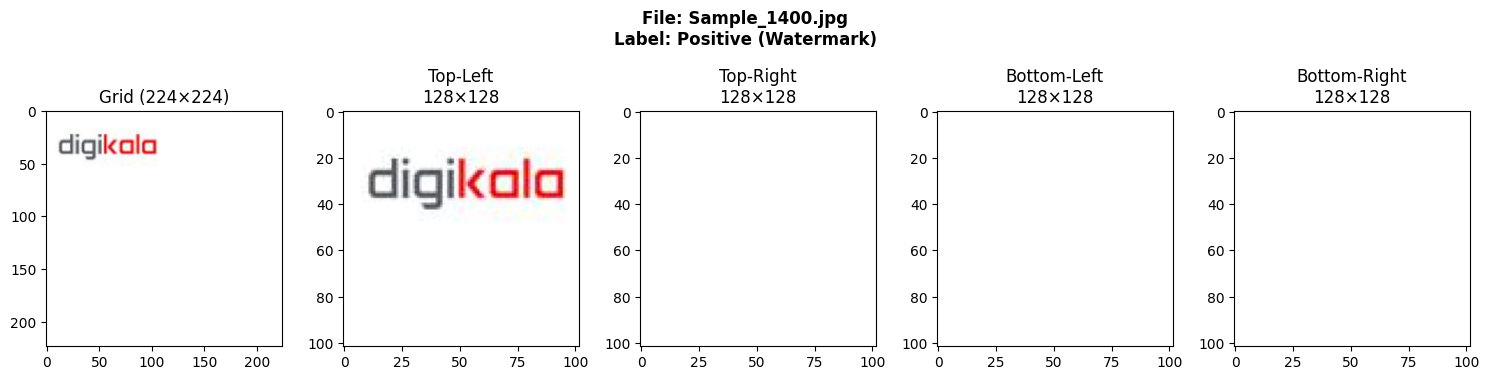

In [177]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import numpy as np
import random

DATA_DIR = "data/train"
class CornerWatermarkDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.labels = []
        self.transform = transform

        for label, class_name in enumerate(["negative", "positive"]):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append(os.path.join(class_dir, fname))
                    self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def _extract_corners(self, img_tensor):
        c, h, w = img_tensor.shape
        s = h // 5
        top_left = img_tensor[:, :s, :s]
        top_right = img_tensor[:, :s, w-s:]
        bottom_left = img_tensor[:, h-s:, :s]
        bottom_right = img_tensor[:, h-s:, w-s:]

        top_row = torch.cat([top_left, top_right], dim=2)
        bottom_row = torch.cat([bottom_left, bottom_right], dim=2)
        grid = torch.cat([top_row, bottom_row], dim=1)

        grid = torch.nn.functional.interpolate(
            grid.unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False
        ).squeeze(0)
        return grid, (top_left, top_right, bottom_left, bottom_right)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if image.size != (512, 512):
            image = image.resize((512, 512))
        if self.transform:
            image = self.transform(image)
        grid, corners = self._extract_corners(image)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return grid, label, corners, img_path

transform = transforms.Compose([
    transforms.ToTensor(),
])

full_dataset = CornerWatermarkDataset(DATA_DIR, transform=transform)

pos_indices = [i for i, label in enumerate(full_dataset.labels) if label == 1]
neg_indices = [i for i, label in enumerate(full_dataset.labels) if label == 0]

selected_pos = random.sample(pos_indices, min(4, len(pos_indices)))
selected_neg = random.sample(neg_indices, min(3, len(neg_indices)))
selected_indices = selected_pos + selected_neg

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
corner_names = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']

for idx, sample_idx in enumerate(selected_indices):
    # اصلاح نام متغیر در اینجا: dataset -> full_dataset
    grid, label, corners, img_path = full_dataset[sample_idx]
    
    # Denormalize
    img_np = grid.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    
    axes[0, idx].imshow(img_np)
    axes[0, idx].set_title(f"{'POS' if label==1 else 'NEG'}\n{os.path.basename(img_path)[:20]}", 
                          fontsize=9, color='green' if label==1 else 'red')
    axes[0, idx].axis('off')

    corners_concat = []
    for i, corner in enumerate(corners):
        corner_np = corner.permute(1, 2, 0).numpy()
        corner_np = np.clip(corner_np, 0, 1)
        corners_concat.append(corner_np)
    
    corners_row1 = np.concatenate([corners_concat[0], corners_concat[1]], axis=1)
    corners_row2 = np.concatenate([corners_concat[2], corners_concat[3]], axis=1)
    corners_all = np.concatenate([corners_row1, corners_row2], axis=0)
    
    axes[1, idx].imshow(corners_all)
    axes[1, idx].set_title('4 Corners (128×128 each)', fontsize=8)
    axes[1, idx].axis('off')

plt.suptitle('Corner Selection Visualization\nTop Row: Grid (224×224) | Bottom Row: Original Corners', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("example:")
print("="*60)

# ۵. بخش مثال تک نمونه (اصلاح نام متغیر)
sample_idx = selected_indices[0]
grid, label, corners, img_path = full_dataset[sample_idx]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
axes[0].imshow(grid.permute(1, 2, 0).numpy())
axes[0].set_title('Grid (224×224)')
axes[0].axis('on')

for i, (corner, name) in enumerate(zip(corners, corner_names)):
    axes[i+1].imshow(corner.permute(1, 2, 0).numpy())
    axes[i+1].set_title(f'{name}\n128×128')
    axes[i+1].axis('on')

plt.suptitle(f'File: {os.path.basename(img_path)}\nLabel: {"Positive (Watermark)" if label==1 else "Negative (Clean)"}', 
             fontweight='bold')
plt.tight_layout()
plt.show()

In [178]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "data/train"
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 10
SEED = 42

In [179]:
val_split_ratio = 0.2
dataset_size = len(full_dataset)
val_size = int(val_split_ratio * dataset_size)
train_size = dataset_size - val_size

In [180]:
train_indices, val_indices = random_split(
    range(dataset_size), [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(Subset(full_dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False)

print(f"Training size: {len(train_indices)} | Validation size: {len(val_indices)}")

Training size: 6866 | Validation size: 1716


In [181]:
class LightCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1: 3x224x224 -> 32x112x112
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            # Block 2: 32x112x112 -> 64x56x56
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            # Block 3: 64x56x56 -> 128x28x28
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
            
            # Block 4: 128x28x28 -> 256x14x14
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
            
            # Global Average Pooling
            nn.AdaptiveAvgPool2d(1),  # 256x1x1
            
            # Classifier
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 1)
        )
        
        # Weight initialization
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.net(x)

model = LightCNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [182]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels, _, _ in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    misclassified_indices = []

    with torch.no_grad():
        for i, (images, labels, _, _) in enumerate(val_loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE).unsqueeze(1).float()

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            errors = (preds != labels).cpu().view(-1)
            if errors.any():
                batch_start = i * BATCH_SIZE
                for j, is_error in enumerate(errors):
                    if is_error:
                        misclassified_indices.append(batch_start + j)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")


np.save("misclassified_indices.npy", np.array(misclassified_indices))



Epoch  1/10 | Train Loss: 2.5341 Acc: 0.5628 | Val Loss: 1.0019 Acc: 0.5140
Epoch  2/10 | Train Loss: 1.9031 Acc: 0.5779 | Val Loss: 0.7310 Acc: 0.6836
Epoch  3/10 | Train Loss: 1.3525 Acc: 0.6280 | Val Loss: 0.5591 Acc: 0.7797
Epoch  4/10 | Train Loss: 1.0626 Acc: 0.6656 | Val Loss: 107.6261 Acc: 0.5117
Epoch  5/10 | Train Loss: 0.9527 Acc: 0.6794 | Val Loss: 0.5557 Acc: 0.7885
Epoch  6/10 | Train Loss: 0.7307 Acc: 0.7354 | Val Loss: 0.5388 Acc: 0.7821
Epoch  7/10 | Train Loss: 0.6461 Acc: 0.7339 | Val Loss: 0.4885 Acc: 0.7826
Epoch  8/10 | Train Loss: 0.6568 Acc: 0.7457 | Val Loss: 0.5475 Acc: 0.7937
Epoch  9/10 | Train Loss: 0.5956 Acc: 0.7489 | Val Loss: 0.4881 Acc: 0.7809
Epoch 10/10 | Train Loss: 0.5483 Acc: 0.7633 | Val Loss: 0.4816 Acc: 0.7955


In [ ]:
torch.save(model, 'LightCNN.pth')

In [183]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

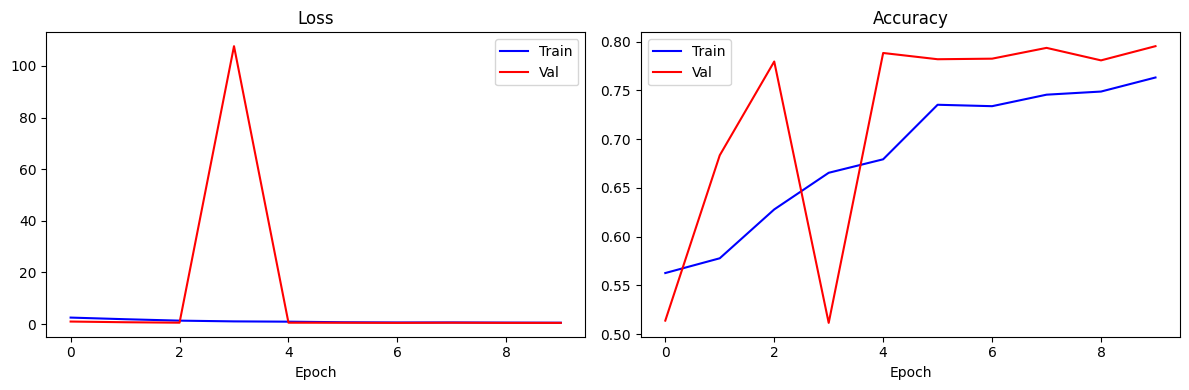


📊 FINAL MODEL METRICS
accuracy score  : 0.7000
precision score : 0.3333
recall score  : 1.0000
f1 Score                   : 0.5000
Best Validation Loss       : 0.481646
Total Parameters           : 1,215,777

✅ Done! Misclassified: 351/8582 samples
Ready for ViT step!


In [184]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Train')
plt.plot(val_losses, 'r-', label='Val')
plt.title('Loss'), plt.xlabel('Epoch'), plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, 'b-', label='Train')
plt.plot(val_accs, 'r-', label='Val')
plt.title('Accuracy'), plt.xlabel('Epoch'), plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("📊 FINAL MODEL METRICS")
print("="*50)
print(f"accuracy score  : {accuracy_score(preds, labels):.4f}")
print(f"precision score : {precision_score(preds, labels):.4f}")
print(f"recall score  : {recall_score(preds, labels):.4f}")
print(f"f1 Score                   : {f1_score(preds, labels):.4f}")
print(f"Best Validation Loss       : {min(val_losses):.6f}")
print(f"Total Parameters           : {sum(p.numel() for p in model.parameters()):,}")
print("="*50)

print(f"\n✅ Done! Misclassified: {len(misclassified_indices)}/{len(dataset)} samples")
print(f"Ready for ViT step!")

In [185]:
import pandas as pd
import os
import torch
from torch.utils.data import DataLoader

class TestCornerWatermarkDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_paths)

    def _extract_corners(self, img_tensor):
        c, h, w = img_tensor.shape
        s = h // 5
        top_left = img_tensor[:, :s, :s]
        top_right = img_tensor[:, :s, w-s:]
        bottom_left = img_tensor[:, h-s:, :s]
        bottom_right = img_tensor[:, h-s:, w-s:]

        top_row = torch.cat([top_left, top_right], dim=2)
        bottom_row = torch.cat([bottom_left, bottom_right], dim=2)
        grid = torch.cat([top_row, bottom_row], dim=1)

        grid = torch.nn.functional.interpolate(
            grid.unsqueeze(0), size=(224, 224), mode='bilinear', align_corners=False
        ).squeeze(0)
        return grid

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        
        if image.size != (512, 512):
            image = image.resize((512, 512))
            
        if self.transform:
            image = self.transform(image)
            
        grid = self._extract_corners(image)
        file_name = os.path.basename(img_path)
        return grid, file_name


test_data = TestCornerWatermarkDataset('data/test/', transform=test_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

model.eval()
predictions = []

print("Starting inference...")
with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        test_preds = (torch.sigmoid(outputs) > 0.5).int()
        
        for i in range(len(filenames)):
            predictions.append({
                "name": filenames[i],
                "predicted": test_preds[i].item()
            })

df = pd.DataFrame(predictions)
df.to_csv("output.csv", index=False)

print("Inference completed! File saved as 'output.csv'")


Starting inference...


PermissionError: [Errno 13] Permission denied: 'output.csv'